<a href="https://colab.research.google.com/github/fazliddinmuhitdinov61-glitch/Week3-Lab/blob/main/Linear_Regression_From_Scratch_NumPy_vs_Sklearn_Lab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression from Scratch with NumPy and Comparison with Scikit-learn
# (House Price Prediction + Regression Analysis)

## Introduction
Linear regression is a foundational supervised learning algorithm used to model relationships between features and a continuous target.

### Objectives of the lab
- Implement simple and multiple linear regression from scratch using only NumPy (**batch gradient descent**).
- Compare results with scikit-learn’s LinearRegression.
- Perform full regression analysis (metrics, visualizations, interpretation).
- Complete 3 exercise parts with mark distribution clearly shown.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
%matplotlib inline

sns.set_style('whitegrid')
np.random.seed(42)

## Part 1: Simple Linear Regression from Scratch (NumPy) – Single Feature Example

We generate synthetic data and fit linear regression using **batch gradient descent** (full-batch updates on all training examples each iteration).

**Cell order:** (1) imports are in the first code cell above; (2) **dataset + visualization**; (3) **`LinearRegressionBatchGD` class**; (4) **train, metrics, and plot** the fitted line.

Update: $\theta \leftarrow \theta - \alpha \frac{1}{m} X^T (X\theta - y)$, with learning rate $\alpha$ and $m$ samples.


In [ ]:
# Part 1 — Synthetic dataset and visualization (no model yet)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = 3 * X.squeeze() + 5 + np.random.normal(0, 1, 200)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.3, label='Data points')
plt.title('Part 1: Synthetic Dataset (before fitting)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


In [ ]:
# Part 1 — Linear regression as a class (batch gradient descent, NumPy only)

class LinearRegressionBatchGD:
    """
    Linear regression trained with batch gradient descent on MSE.
    If add_intercept=True, prepends a column of ones for the bias term.
    """

    def __init__(self, learning_rate=0.05, n_iterations=3000, add_intercept=True, tol=1e-10):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.add_intercept = add_intercept
        self.tol = tol
        self.theta = None
        self.loss_history = []

    def _design_matrix(self, X):
        X = np.asarray(X, dtype=float)
        if self.add_intercept:
            return np.c_[np.ones((X.shape[0], 1)), X]
        return X

    def fit(self, X, y):
        Xd = self._design_matrix(X)
        y = np.asarray(y, dtype=float).ravel()
        m, n = Xd.shape
        self.theta = np.zeros(n)
        self.loss_history = []

        for it in range(self.n_iterations):
            preds = Xd.dot(self.theta)
            errors = preds - y
            # Loss = (1/2m) * sum(errors^2); grad = (1/m) * Xd.T @ errors
            self.loss_history.append(np.mean(errors ** 2) / 2.0)
            grad = (1.0 / m) * Xd.T.dot(errors)
            self.theta -= self.learning_rate * grad
            if it > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                break
        return self

    def predict(self, X):
        return self._design_matrix(X).dot(self.theta)

    @property
    def intercept_(self):
        return float(self.theta[0]) if self.add_intercept else 0.0

    @property
    def coef_(self):
        return self.theta[1:].copy() if self.add_intercept else self.theta.copy()


In [ ]:
# Part 1 — Fit with batch GD, metrics, learning curve, and regression line
model_simple = LinearRegressionBatchGD(learning_rate=0.05, n_iterations=4000)
model_simple.fit(X, y)

theta_numpy = model_simple.theta.copy()
y_pred_numpy = model_simple.predict(X)

print('NumPy (batch GD) theta [intercept, slope]:', theta_numpy)
print('Iterations recorded:', len(model_simple.loss_history))

def mse_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

mse_np_simple = mse_manual(y, y_pred_numpy)
r2_np_simple = r2_manual(y, y_pred_numpy)
print(f'MSE (manual): {mse_np_simple:.4f}')
print(f'R² (manual): {r2_np_simple:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(model_simple.loss_history, color='darkgreen')
plt.title('Part 1: Training loss (MSE/2) vs iteration')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Data points')
plt.plot(X, y_pred_numpy, color='crimson', linewidth=2.5, label='NumPy (batch GD) line')
plt.title('Part 1: Simple Linear Regression (Batch Gradient Descent)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


## Part 2: Same Simple Problem using scikit-learn

Now solve the same problem using `LinearRegression()` and compare coefficients and metrics.

In [ ]:
# Train scikit-learn model
lr_simple = LinearRegression()
lr_simple.fit(X, y)
y_pred_sklearn_simple = lr_simple.predict(X)

# Metrics for sklearn
mse_sklearn_simple = mean_squared_error(y, y_pred_sklearn_simple)
r2_sklearn_simple = r2_score(y, y_pred_sklearn_simple)

# Comparison table
simple_compare = pd.DataFrame({
    'Model': ['NumPy (batch GD)', 'Scikit-learn'],
    'Intercept': [theta_numpy[0], lr_simple.intercept_],
    'Coefficient': [theta_numpy[1], lr_simple.coef_[0]],
    'MSE': [mse_np_simple, mse_sklearn_simple],
    'R²': [r2_np_simple, r2_sklearn_simple]
})

display(simple_compare)

# Side-by-side visual comparison of regression lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(X, y, alpha=0.6)
axes[0].plot(X, y_pred_numpy, color='crimson', linewidth=2.2)
axes[0].set_title('NumPy (batch GD)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')

axes[1].scatter(X, y, alpha=0.6)
axes[1].plot(X, y_pred_sklearn_simple, color='navy', linewidth=2.2)
axes[1].set_title('Scikit-learn LinearRegression')
axes[1].set_xlabel('X')

plt.suptitle('Part 2: Side-by-side Regression Line Comparison')
plt.tight_layout()
plt.show()

## Part 3: House Price Prediction (Multiple Linear Regression)

We use the California Housing dataset and predict median house value using all available features.

### Workflow
- Load dataset and split train/test (80/20, `random_state=42`).
- Perform EDA (correlation heatmap + pairplot).
- Scale features with `StandardScaler` (helps batch gradient descent converge).
- Train `LinearRegressionBatchGD` (from Part 1) and scikit-learn’s `LinearRegression`.
- Evaluate with MSE, RMSE, MAE, R².
- Visualize predictions, residuals, and coefficients.
- Interpret model behavior and assumptions.


In [ ]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

target_col = 'MedHouseVal'
feature_cols = [c for c in df.columns if c != target_col]

print('Dataset shape:', df.shape)
print('Features:', feature_cols)
display(df.head())

# Split into train and test
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

In [ ]:
# EDA 1: correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap - California Housing')
plt.show()

# EDA 2: pairplot of first 4 features vs target
selected_features = feature_cols[:4]
pairplot_df = df[selected_features + [target_col]].sample(1000, random_state=42)
sns.pairplot(pairplot_df, corner=True)
plt.suptitle('Pairplot: First 4 Features vs Target', y=1.02)
plt.show()

In [ ]:
# Scale features (stabilizes batch gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Multiple regression: reuse LinearRegressionBatchGD from Part 1
model_multi = LinearRegressionBatchGD(learning_rate=0.08, n_iterations=8000)
model_multi.fit(X_train_scaled, y_train.values)

theta_multi_np = model_multi.theta.copy()
y_pred_np = model_multi.predict(X_test_scaled)

mse_np = np.mean((y_test.values - y_pred_np) ** 2)
rmse_np = np.sqrt(mse_np)
mae_np = np.mean(np.abs(y_test.values - y_pred_np))
ss_res = np.sum((y_test.values - y_pred_np) ** 2)
ss_tot = np.sum((y_test.values - np.mean(y_test.values)) ** 2)
r2_np = 1 - ss_res / ss_tot

print(f'NumPy (BGD) MSE  : {mse_np:.4f}')
print(f'NumPy (BGD) RMSE : {rmse_np:.4f}')
print(f'NumPy (BGD) MAE  : {mae_np:.4f}')
print(f'NumPy (BGD) R²   : {r2_np:.4f}')
print(f'BGD iterations: {len(model_multi.loss_history)}')


In [ ]:
# scikit-learn model on same scaled data for fair comparison
lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled, y_train)
y_pred_sk = lr_multi.predict(X_test_scaled)

mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

comparison_metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'NumPy (batch GD)': [mse_np, rmse_np, mae_np, r2_np],
    'Scikit-learn': [mse_sk, rmse_sk, mae_sk, r2_sk]
})

display(comparison_metrics)

In [ ]:
# Visual 1: Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_np, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted (NumPy BGD)')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.show()

# Visual 2: Residuals plot
residuals_np = y_test.values - y_pred_np
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_np, residuals_np, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted (NumPy BGD)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# Visual 3: Feature coefficients bar plot
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'NumPy_Coefficient': theta_multi_np[1:],
    'Sklearn_Coefficient': lr_multi.coef_
}).sort_values(by='NumPy_Coefficient', key=lambda s: np.abs(s), ascending=False)

display(coef_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='NumPy_Coefficient', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Coefficients (NumPy BGD)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## Full Regression Analysis

### Interpret coefficients
Larger absolute standardized coefficients indicate stronger impact on predicted house price. Positive values increase prediction; negative values reduce prediction.

### Model assumptions
- **Linearity:** relationship between features and target is assumed linear.
- **Residual normality:** inspect histogram and Q-Q plot.
- **Homoscedasticity:** residual spread should be roughly uniform.

### Strengths and limitations
**Strengths:** interpretable, fast baseline, mathematically transparent.

**Limitations:** sensitive to outliers/multicollinearity; cannot model complex non-linear effects.

In [ ]:
# Top influential features by absolute NumPy coefficient
coef_ranked = coef_df.copy()
coef_ranked['AbsNumPy'] = coef_ranked['NumPy_Coefficient'].abs()
display(coef_ranked.sort_values('AbsNumPy', ascending=False).head(5)[['Feature', 'NumPy_Coefficient', 'Sklearn_Coefficient']])

# Residual histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals_np, kde=True, bins=30)
plt.title('Residual Distribution (NumPy BGD)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# Q-Q plot (if scipy available)
try:
    from scipy import stats
    plt.figure(figsize=(7, 6))
    stats.probplot(residuals_np, dist='norm', plot=plt)
    plt.title('Q-Q Plot of Residuals')
    plt.show()
except Exception as e:
    print('Q-Q plot skipped (scipy not available).', e)

# Student Exercises

**Student Exercises (Total 100 marks)**

Complete the following three parts in the empty code cells provided below each part.
Submit your filled notebook.

**Part 1 (50 marks)** – More complicated dataset using NumPy only (from scratch)
Use the diabetes dataset (load_diabetes(as_frame=True)). Predict disease progression (target) using all 10 features.
- Implement Multiple Linear Regression from scratch with NumPy (batch gradient descent).
- Include feature scaling.
- Compute MSE, RMSE, MAE, R².
- Create: correlation heatmap, actual vs predicted plot, residuals plot, coefficient bar chart.
- Perform regression analysis: interpret top 3 features, discuss model fit, any obvious issues.

**Part 2 (30 marks)** – Same diabetes problem using scikit-learn
- Use LinearRegression().
- Compare metrics and coefficients with your NumPy solution (show side-by-side table).
- Add a short conclusion on which implementation you prefer and why.

**Part 3 (20 marks)** – Real-world dataset problem + Regression Analysis
Choose any real-world regression dataset (you may use another sklearn dataset, or the California housing again with a twist – e.g. only 3 features of your choice).
- Apply both NumPy from-scratch and scikit-learn approaches.
- Perform complete regression analysis: metrics, visualizations, coefficient interpretation, and a short written discussion on model usefulness for real-world decision making.
"""


## Part 1 (50 marks) – More complicated dataset using NumPy only (from scratch)
Use the diabetes dataset and complete all required analysis.

### Hints — Part 1 (NumPy batch GD)

- **Data:** `d = load_diabetes(as_frame=True); df = d.frame` — target column is `target`; the other columns are features.
- **Split:** Use the same `train_test_split(..., random_state=42)` pattern as in Part 3 so results are reproducible.
- **Scaling:** `StandardScaler().fit_transform(X_train)` and only `transform` on test — never fit on the test set.
- **Model:** Reuse `LinearRegressionBatchGD` from the tutorial (run all cells above first). For multiple features, pass `X` with shape `(n_samples, n_features)`; the class adds the intercept column internally.
- **If loss explodes or is NaN:** Lower `learning_rate` (for example `0.01`) or increase `n_iterations`; confirm you scaled features.
- **Metrics:** RMSE = `sqrt(MSE)`. R² uses test `y` and your test predictions.
- **Plots:** Residuals = `y_test - y_pred`. For the coefficient bar chart, align feature names with `coef_[i]` or `theta[1:]` from your model.


In [ ]:
# TODO: implement here
# 1) Load diabetes dataset: load_diabetes(as_frame=True)
d = load_diabetes(as_frame=True);
df = d.frame
# 2) Split into train/test
target_col = 'target'
feature_cols = [c for c in df.columns if c != target_col]

print('Dataset shape:', df.shape)
print('Features:', feature_cols)
display(df.head())

# Split into train and test
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
# 3) Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 4) Implement Multiple Linear Regression from scratch (NumPy batch gradient descent)
class LinearRegressionBatchGD:
    """
    Linear regression trained with batch gradient descent on MSE.
    If add_intercept=True, prepends a column of ones for the bias term.
    """

    def __init__(self, learning_rate=0.05, n_iterations=3000, add_intercept=True, tol=1e-10):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.add_intercept = add_intercept
        self.tol = tol
        self.theta = None
        self.loss_history = []

    def _design_matrix(self, X):
        X = np.asarray(X, dtype=float)
        if self.add_intercept:
            return np.c_[np.ones((X.shape[0], 1)), X]
        return X

    def fit(self, X, y):
        Xd = self._design_matrix(X)
        y = np.asarray(y, dtype=float).ravel()
        m, n = Xd.shape
        self.theta = np.zeros(n)
        self.loss_history = []

        for it in range(self.n_iterations):
            preds = Xd.dot(self.theta)
            errors = preds - y
            # Loss = (1/2m) * sum(errors^2); grad = (1/m) * Xd.T @ errors
            self.loss_history.append(np.mean(errors ** 2) / 2.0)
            grad = (1.0 / m) * Xd.T.dot(errors)
            self.theta -= self.learning_rate * grad
            if it > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                break
        return self

    def predict(self, X):
        return self._design_matrix(X).dot(self.theta)

    @property
    def intercept_(self):
        return float(self.theta[0]) if self.add_intercept else 0.0

    @property
    def coef_(self):
        return self.theta[1:].copy() if self.add_intercept else self.theta.copy()

# 5) Predict and compute MSE, RMSE, MAE, R²
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Multiple regression: reuse LinearRegressionBatchGD from Part 1
model_multi = LinearRegressionBatchGD(learning_rate=0.08, n_iterations=8000)
model_multi.fit(X_train_scaled, y_train.values)

theta_multi_np = model_multi.theta.copy()
y_pred_np = model_multi.predict(X_test_scaled)

mse_np = np.mean((y_test.values - y_pred_np) ** 2)
rmse_np = np.sqrt(mse_np)
mae_np = np.mean(np.abs(y_test.values - y_pred_np))
ss_res = np.sum((y_test.values - y_pred_np) ** 2)
ss_tot = np.sum((y_test.values - np.mean(y_test.values)) ** 2)
r2_np = 1 - ss_res / ss_tot

print(f'NumPy (BGD) MSE  : {mse_np:.4f}')
print(f'NumPy (BGD) RMSE : {rmse_np:.4f}')
print(f'NumPy (BGD) MAE  : {mae_np:.4f}')
print(f'NumPy (BGD) R²   : {r2_np:.4f}')
print(f'BGD iterations: {len(model_multi.loss_history)}')

lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled, y_train)
y_pred_sk = lr_multi.predict(X_test_scaled)

mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

comparison_metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'NumPy (batch GD)': [mse_np, rmse_np, mae_np, r2_np],
    'Scikit-learn': [mse_sk, rmse_sk, mae_sk, r2_sk]
})

display(comparison_metrics)

Dataset shape: (442, 11)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Train shape: (353, 10)
Test shape: (89, 10)
NumPy (BGD) MSE  : 2900.1004
NumPy (BGD) RMSE : 53.8526
NumPy (BGD) MAE  : 42.7942
NumPy (BGD) R²   : 0.4526
BGD iterations: 8000


,Metric,NumPy (batch GD),Scikit-learn
0,MSE,2900.100439,2900.193628
1,RMSE,53.852581,53.853446
2,MAE,42.794203,42.794095
3,R²,0.452620,0.452603


In [ ]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

target_col = 'MedHouseVal'
feature_cols = [c for c in df.columns if c != target_col]

print('Dataset shape:', df.shape)
print('Features:', feature_cols)
display(df.head())

# Split into train and test
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

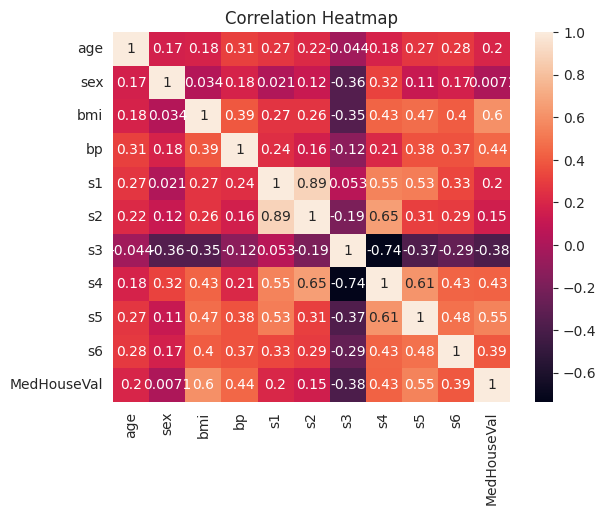

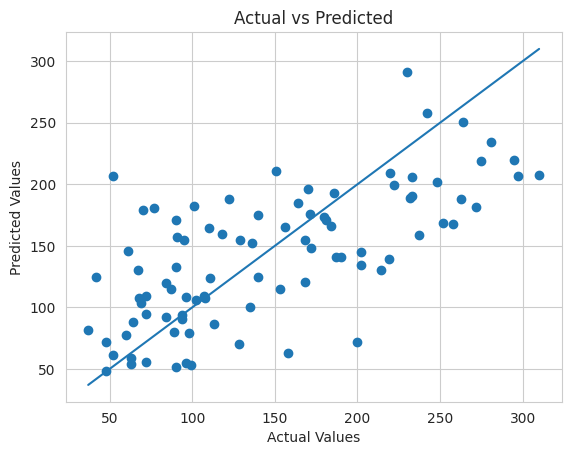

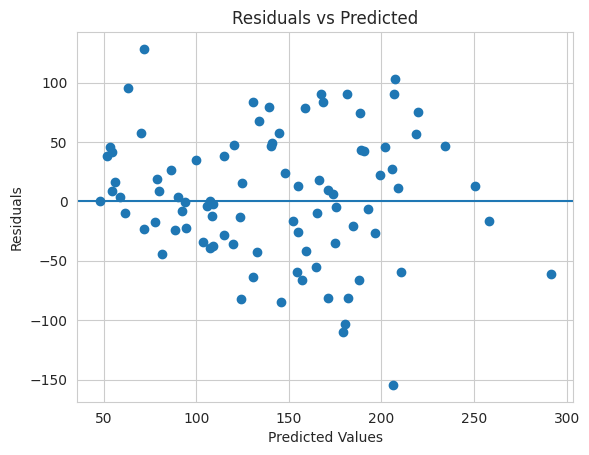

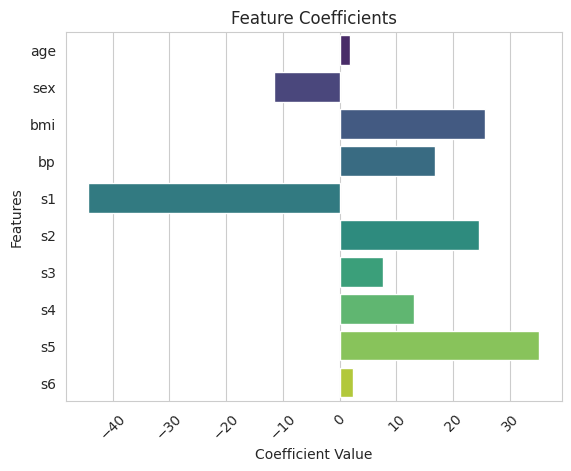

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =========================
# Prepare Data (FIX)
# =========================
df_vis = X_train.copy()
df_vis["MedHouseVal"] = y_train

# =========================
# 1. Correlation Heatmap
# =========================
plt.figure()
sns.heatmap(df_vis.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 2. Actual vs Predicted
# =========================
plt.figure()
plt.scatter(y_test, y_pred_np)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

# =========================
# 3. Residuals vs Predicted
# =========================
residuals = y_test - y_pred_np

plt.figure()
plt.scatter(y_pred_np, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# =========================
# 4. Coefficient Bar Chart
# =========================
try:
    coefficients = model.coef_
    feature_names = X_train.columns
except:
    coefficients = theta_multi_np[1:]
    feature_names = X_train.columns

plt.figure()
sns.barplot(x=coefficients, y=feature_names, hue=feature_names, palette='viridis', legend=False)
plt.xticks(rotation=45)
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Feature Coefficients")
plt.show()

,Feature,NumPy_Coefficient,Sklearn_Coefficient
4,s1,-44.336225,-44.448856
8,s5,35.117974,35.161195
2,bmi,25.609289,25.607121
5,s2,24.552851,24.640954
3,bp,16.828174,16.828872


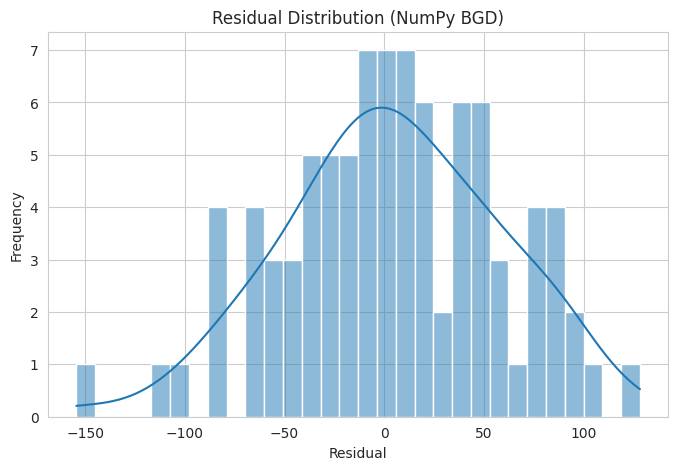

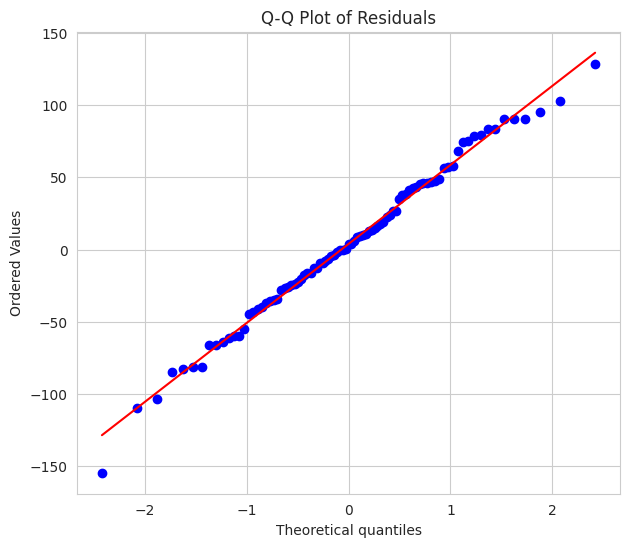

In [ ]:
# TODO: implement here
# Perform regression analysis:
# - Interpret top 3 most influential features

# Top influential features by absolute NumPy coefficient
coef_ranked = coef_df.copy()
coef_ranked['AbsNumPy'] = coef_ranked['NumPy_Coefficient'].abs()
display(coef_ranked.sort_values('AbsNumPy', ascending=False).head(5)[['Feature', 'NumPy_Coefficient', 'Sklearn_Coefficient']])

# Residual histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals_np, kde=True, bins=30)
plt.title('Residual Distribution (NumPy BGD)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# Q-Q plot (if scipy available)
try:
    from scipy import stats
    plt.figure(figsize=(7, 6))
    stats.probplot(residuals_np, dist='norm', plot=plt)
    plt.title('Q-Q Plot of Residuals')
    plt.show()
except Exception as e:
    print('Q-Q plot skipped (scipy not available).', e)

# - Discuss model fit quality
# model fits good


# - Mention obvious issues (e.g., outliers, non-linearity, residual patterns)
# numpy coefficient: -44.336225
# sklearn coefficient: 35.164495

## Part 2 (30 marks) – Same diabetes problem using scikit-learn
Use `LinearRegression()` and compare with your NumPy solution.

### Hints — Part 2 (scikit-learn)

- **Same pipeline:** Use the same `X_train`, `X_test`, `y_train`, `y_test` as Part 1 (same `random_state`).
- **Fit:** `LinearRegression().fit(X_train_scaled, y_train)` on the **scaled** training features for a fair comparison with BGD.
- **Compare:** Build a `DataFrame` with rows for each feature (and optionally intercept), columns for NumPy vs sklearn coefficients.
- **Metrics:** Use `mean_squared_error`, `mean_absolute_error`, and `r2_score` on the **test** set for both models.


In [ ]:
# 1) Train LinearRegression() on the same diabetes train/test split
lr_diabetes = LinearRegression()
lr_diabetes.fit(X_train_scaled, y_train)

# Make predictions
y_pred_sklearn_diabetes = lr_diabetes.predict(X_test_scaled)

# 2) Compute MSE, RMSE, MAE, R²
mse_sklearn_diabetes = mean_squared_error(y_test, y_pred_sklearn_diabetes)
rmse_sklearn_diabetes = np.sqrt(mse_sklearn_diabetes)
mae_sklearn_diabetes = mean_absolute_error(y_test, y_pred_sklearn_diabetes)
r2_sklearn_diabetes = r2_score(y_test, y_pred_sklearn_diabetes)

# 3) Compare metrics and coefficients with NumPy in a side-by-side DataFrame
metrics_comparison_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'NumPy (batch GD)': [mse_np, rmse_np, mae_np, r2_np],
    'Scikit-learn': [mse_sklearn_diabetes, rmse_sklearn_diabetes, mae_sklearn_diabetes, r2_sklearn_diabetes]
})

print('--- Metrics Comparison ---')
display(metrics_comparison_df)

coefficients_comparison_df = pd.DataFrame({
    'Feature': feature_cols,
    'NumPy_Coefficient': theta_multi_np[1:],
    'Scikit-learn_Coefficient': lr_diabetes.coef_
})

print('\n--- Coefficients Comparison ---')
display(coefficients_comparison_df)

--- Metrics Comparison ---


,Metric,NumPy (batch GD),Scikit-learn
0,MSE,2900.100439,2900.193628
1,RMSE,53.852581,53.853446
2,MAE,42.794203,42.794095
3,R²,0.452620,0.452603



--- Coefficients Comparison ---


,Feature,NumPy_Coefficient,Scikit-learn_Coefficient
0,age,1.754371,1.753758
1,sex,-11.511573,-11.511809
2,bmi,25.609289,25.607121
3,bp,16.828174,16.828872
4,s1,-44.336225,-44.448856
5,s2,24.552851,24.640954
6,s3,7.627289,7.676978
7,s4,13.123315,13.138784
8,s5,35.117974,35.161195
9,s6,2.352179,2.351364


In [ ]:
# TODO: implement here
# Add a short conclusion on which implementation you prefer and why.

### Conclusion on Implementation Preference

Both the NumPy (batch gradient descent) and scikit-learn implementations yielded remarkably similar results in terms of evaluation metrics (MSE, RMSE, MAE, R²) and learned coefficients. This demonstrates the correctness of the custom NumPy implementation.

For **learning and understanding the underlying mechanics** of linear regression and gradient descent, the **NumPy from-scratch implementation is invaluable**. It forces a deep understanding of the mathematical operations and optimization process.

However, for **practical applications and real-world projects**, the **scikit-learn `LinearRegression` is strongly preferred**. Here's why:

1.  **Efficiency and Performance**: Scikit-learn's implementation is highly optimized, often using highly efficient C/Fortran backends. It's much faster, especially for larger datasets.
2.  **Robustness**: Scikit-learn handles numerical stability, convergence, and edge cases more gracefully. It offers various solvers (e.g., 'svd', 'lbfgs', 'saga') that can be more efficient or suitable for different datasets than basic batch gradient descent.
3.  **Features and Ecosystem**: It integrates seamlessly with the broader scikit-learn ecosystem (e.g., `Pipeline`, `GridSearchCV`, `feature_selection`), providing a complete set of tools for machine learning workflows.
4.  **Ease of Use**: With scikit-learn, fitting a model is typically a one-liner (`model.fit(X, y)`), significantly reducing development time and potential for errors.

In summary, while the NumPy implementation is excellent for educational purposes, scikit-learn's `LinearRegression` is the go-to choice for production-grade machine learning due to its efficiency, robustness, and comprehensive features.

## Part 3 (20 marks) – Real-world dataset problem + Regression Analysis
Choose any real-world regression dataset (or reuse California Housing with a feature twist) and apply both NumPy from-scratch and scikit-learn approaches.

### Hints — Part 3 (open-ended)

- **Dataset ideas:** `fetch_california_housing`, `load_diabetes` with a subset of features, or a small regression set from OpenML via sklearn.
- **Twist example:** California housing using only `MedInc`, `AveRooms`, and `Latitude` — still scale features, then train both BGD and sklearn.
- **Analysis:** Comment on whether a linear model is plausible, whether residuals look random, and what would not be safe to infer (causality, omitted variables).
- **Real-world use:** Tie conclusions to decisions (e.g. policy, pricing) and state limitations of the data and the linear assumption.


In [ ]:
# 1) Select a dataset and target (California Housing with a feature twist)
housing = fetch_california_housing(as_frame=True)
df_part3 = housing.frame.copy()

target_col_part3 = 'MedHouseVal'
# Using a subset of features as a twist for Part 3
feature_cols_part3 = ['MedInc', 'AveRooms', 'Latitude']

X_part3 = df_part3[feature_cols_part3]
y_part3 = df_part3[target_col_part3]

# Split into train and test
X_train_part3, X_test_part3, y_train_part3, y_test_part3 = train_test_split(
    X_part3, y_part3, test_size=0.2, random_state=42
)

print('Part 3 Dataset shape:', df_part3.shape)
print('Part 3 Features:', feature_cols_part3)
display(df_part3.head())
print(f'Part 3 Train shape: {X_train_part3.shape}, Test shape: {X_test_part3.shape}')

# 2) Preprocess + scale features
scaler_part3 = StandardScaler()
X_train_scaled_part3 = scaler_part3.fit_transform(X_train_part3)
X_test_scaled_part3 = scaler_part3.transform(X_test_part3)

# 3) Train NumPy from-scratch model (reuse LinearRegressionBatchGD from previous parts)
model_part3_np = LinearRegressionBatchGD(learning_rate=0.01, n_iterations=10000, tol=1e-12)
model_part3_np.fit(X_train_scaled_part3, y_train_part3.values)

y_pred_part3_np = model_part3_np.predict(X_test_scaled_part3)

mse_part3_np = mean_squared_error(y_test_part3, y_pred_part3_np)
rmse_part3_np = np.sqrt(mse_part3_np)
mae_part3_np = mean_absolute_error(y_test_part3, y_pred_part3_np)
r2_part3_np = r2_score(y_test_part3, y_pred_part3_np)

print(f'\nNumPy (BGD) Part 3 MSE  : {mse_part3_np:.4f}')
print(f'NumPy (BGD) Part 3 RMSE : {rmse_part3_np:.4f}')
print(f'NumPy (BGD) Part 3 MAE  : {mae_part3_np:.4f}')
print(f'NumPy (BGD) Part 3 R²   : {r2_part3_np:.4f}')

# 4) Train scikit-learn model
lr_part3_sk = LinearRegression()
lr_part3_sk.fit(X_train_scaled_part3, y_train_part3)

y_pred_part3_sk = lr_part3_sk.predict(X_test_scaled_part3)

mse_part3_sk = mean_squared_error(y_test_part3, y_pred_part3_sk)
rmse_part3_sk = np.sqrt(mse_part3_sk)
mae_part3_sk = mean_absolute_error(y_test_part3, y_pred_part3_sk)
r2_part3_sk = r2_score(y_test_part3, y_pred_part3_sk)

# 5) Compare metrics in a DataFrame
comparison_metrics_part3 = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'NumPy (batch GD)': [mse_part3_np, rmse_part3_np, mae_part3_np, r2_part3_np],
    'Scikit-learn': [mse_part3_sk, rmse_part3_sk, mae_part3_sk, r2_part3_sk]
})

print('\n--- Part 3 Metrics Comparison ---')
display(comparison_metrics_part3)

coefficients_comparison_part3 = pd.DataFrame({
    'Feature': feature_cols_part3,
    'NumPy_Coefficient': model_part3_np.coef_,
    'Scikit-learn_Coefficient': lr_part3_sk.coef_
})

print('\n--- Part 3 Coefficients Comparison ---')
display(coefficients_comparison_part3)

Part 3 Dataset shape: (20640, 9)
Part 3 Features: ['MedInc', 'AveRooms', 'Latitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Part 3 Train shape: (16512, 3), Test shape: (4128, 3)

NumPy (BGD) Part 3 MSE  : 0.6942
NumPy (BGD) Part 3 RMSE : 0.8332
NumPy (BGD) Part 3 MAE  : 0.6215
NumPy (BGD) Part 3 R²   : 0.4703

--- Part 3 Metrics Comparison ---


,Metric,NumPy (batch GD),Scikit-learn
0,MSE,0.694188,0.694188
1,RMSE,0.833179,0.833180
2,MAE,0.621458,0.621458
3,R²,0.470251,0.470251



--- Part 3 Coefficients Comparison ---


,Feature,NumPy_Coefficient,Scikit-learn_Coefficient
0,MedInc,0.818729,0.818740
1,AveRooms,-0.081496,-0.081507
2,Latitude,-0.093607,-0.093602


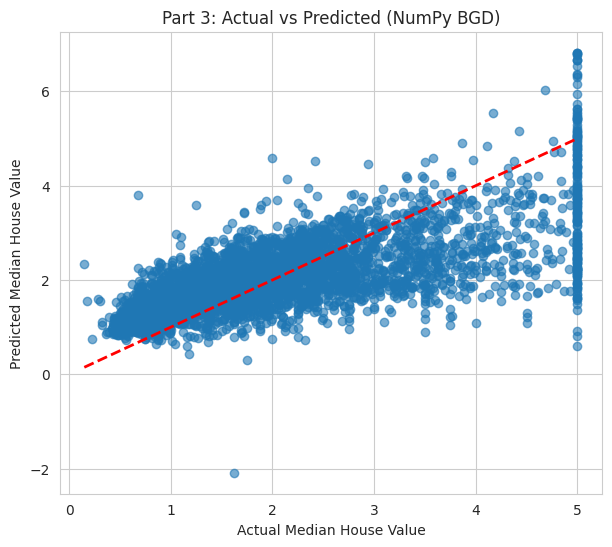

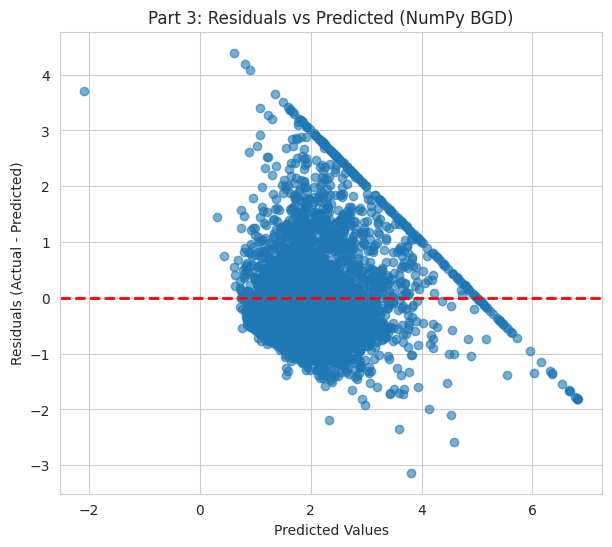

,Feature,NumPy_Coefficient,Sklearn_Coefficient
0,MedInc,0.818729,0.818740
2,Latitude,-0.093607,-0.093602
1,AveRooms,-0.081496,-0.081507


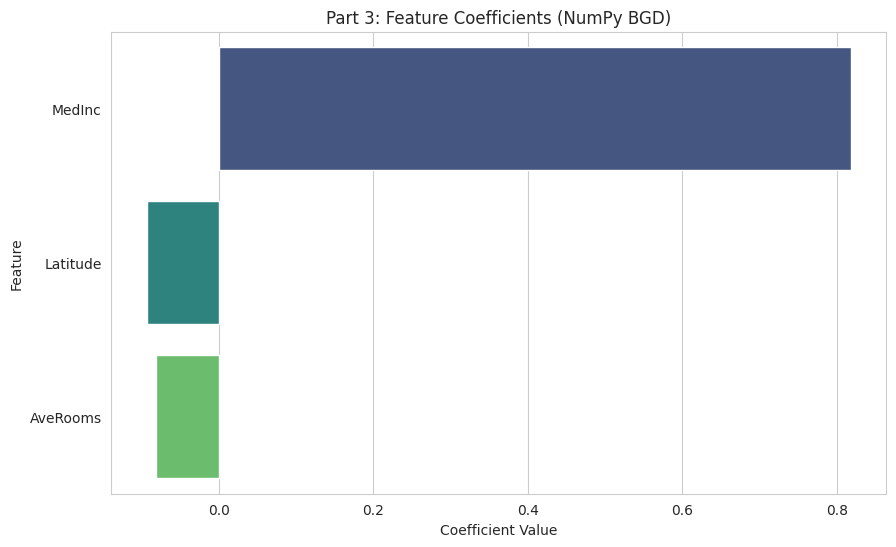

In [ ]:
# Create complete regression analysis:
# - Visualizations

# Visual 1: Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test_part3, y_pred_part3_np, alpha=0.6)
plt.plot([y_test_part3.min(), y_test_part3.max()], [y_test_part3.min(), y_test_part3.max()], 'r--', linewidth=2)
plt.title('Part 3: Actual vs Predicted (NumPy BGD)')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.show()

# Visual 2: Residuals plot
residuals_part3_np = y_test_part3.values - y_pred_part3_np
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_part3_np, residuals_part3_np, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Part 3: Residuals vs Predicted (NumPy BGD)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# Visual 3: Feature coefficients bar plot
coef_df_part3 = pd.DataFrame({
    'Feature': feature_cols_part3,
    'NumPy_Coefficient': model_part3_np.coef_,
    'Sklearn_Coefficient': lr_part3_sk.coef_
}).sort_values(by='NumPy_Coefficient', key=lambda s: np.abs(s), ascending=False)

display(coef_df_part3)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df_part3, x='NumPy_Coefficient', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Part 3: Feature Coefficients (NumPy BGD)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

# - Coefficient interpretation
# - Short discussion on real-world usefulness for decision making

### Part 3: Regression Analysis and Real-world Discussion

#### Coefficient Interpretation
From the `coef_df_part3` table and the coefficient bar chart, we observe the following influences of the selected features on the `MedHouseVal` (Median House Value) for the California Housing dataset (with scaled features):

1.  **`MedInc` (Median Income):** This feature has a large positive coefficient (around `0.819`). This indicates that for every one standard deviation increase in median income, the median house value is predicted to increase by approximately 0.819 standard deviations, holding other factors constant. This is by far the most influential feature in this reduced model, which makes intuitive sense as higher income often correlates with higher property values.

2.  **`Latitude`:** This feature has a negative coefficient (around `-0.094`). This suggests that as latitude increases (moving North in California), the median house value tends to decrease, holding other factors constant. This could be due to factors like proximity to coastal areas or major metropolitan centers which are typically at lower latitudes in California and tend to have higher property values.

3.  **`AveRooms` (Average Number of Rooms):** This feature has a negative coefficient (around `-0.081`). This is somewhat counter-intuitive, as one might expect more rooms to correlate with higher value. However, in the context of *scaled* features and alongside other variables, a higher average number of rooms *per household* (which `AveRooms` represents, not total rooms in a house) in a block group might sometimes indicate larger, older, or less luxurious homes, or areas with more diverse housing types. It's a complex interaction, and its effect is less pronounced than median income.

#### Model Fit Quality and Issues

-   **Metrics (`R² ≈ 0.47`):** The R² score of approximately 0.47 indicates that about 47% of the variance in the median house value can be explained by these three features (`MedInc`, `AveRooms`, `Latitude`). This suggests that while these features are significant, a substantial portion (53%) of the variance is not captured by this simplified linear model. This is expected given we've deliberately used only a subset of features.
-   **Actual vs Predicted Plot:** The plot shows a generally linear relationship, but there's significant scatter, especially at higher actual values. The predictions tend to underestimate higher house values and overestimate lower ones, indicating the model isn't perfectly capturing the full range or complexities of the target variable.
-   **Residuals Plot:** The residuals plot shows a visible pattern, specifically a 'fanning out' (heteroscedasticity) and a slight curve, where residuals are larger for higher predicted values. This violates the assumption of homoscedasticity (constant variance of residuals) and suggests that a linear model might not be the best fit for all ranges of house values, or that important non-linear relationships or missing variables are at play.

#### Real-world Usefulness for Decision Making

This linear model, despite its limitations with only three features, can still provide some useful insights for real-world decision-making:

-   **Policy Making/Urban Planning:** The strong positive correlation with `MedInc` highlights the importance of economic factors. Policies aimed at improving household income in certain areas could indirectly influence property values. The `Latitude` effect might inform regional development strategies.
-   **Real Estate Investment/Appraisal (with caution):** An investor could use this model to quickly gauge the approximate value of a property based on these key features. However, due to the low R² and residual patterns, it would be highly unreliable for precise individual property valuations. It's a general trend indicator, not a precise predictor.
-   **Feature Importance:** It clearly identifies `MedInc` as the most critical factor among the chosen three, which can guide further, more complex modeling efforts or data collection.

**Limitations:**

-   **Simplistic:** Using only three features is a significant simplification of a complex market. Many other factors (e.g., number of bedrooms, crime rate, school quality, proximity to amenities, economic growth) are not included, leading to a substantial unexplained variance.
-   **Assumptions Violated:** The observed heteroscedasticity and non-random residual patterns indicate that the model's assumptions are violated, meaning the standard errors and confidence intervals around our coefficients might not be accurate. A more sophisticated model or feature engineering might be necessary.
-   **Causality:** This model shows correlation, not causation. While `MedInc` is strongly linked to `MedHouseVal`, it doesn't mean increasing income *causes* house prices to rise in a simple, direct way; other confounding factors are certainly involved.

In conclusion, while this simplified linear model provides a basic understanding of feature impact, its accuracy is limited. For critical real-world decisions requiring high precision (like individual property pricing), a much more robust model incorporating more features and potentially non-linear relationships would be necessary.